In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [4]:
df = pd.read_csv("very_final_dataset.csv")
df["position"] = df["position"].astype('category')

X = df.iloc[:,1:]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y = df['scored_after']

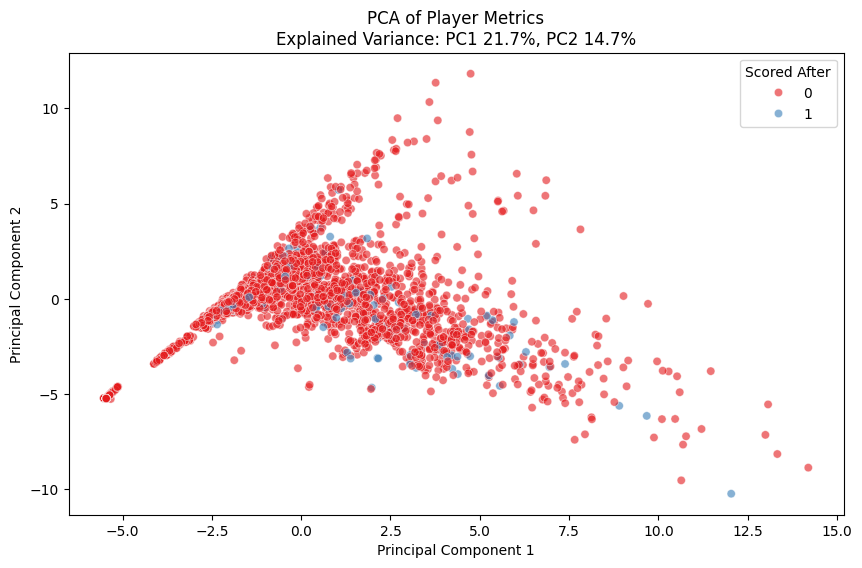

In [5]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]

# PCA Scatter Plot
plt.figure(figsize=(10, 6))

is_binary = df['scored_after'].nunique() <= 2
hue_type = df['scored_after'].astype(str) if is_binary else 'scored_after'

sns.scatterplot(
    x='PCA1', y='PCA2',
    hue=hue_type,
    data=df,
    palette='Set1' if is_binary else 'viridis',
    alpha=0.6
)
plt.title(f'PCA of Player Metrics\nExplained Variance: PC1 {pca.explained_variance_ratio_[0]*100:.1f}%, PC2 {pca.explained_variance_ratio_[1]*100:.1f}%')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Scored After')

Text(0.5, 1.0, 'Correlation of Numeric Features with scored_after')

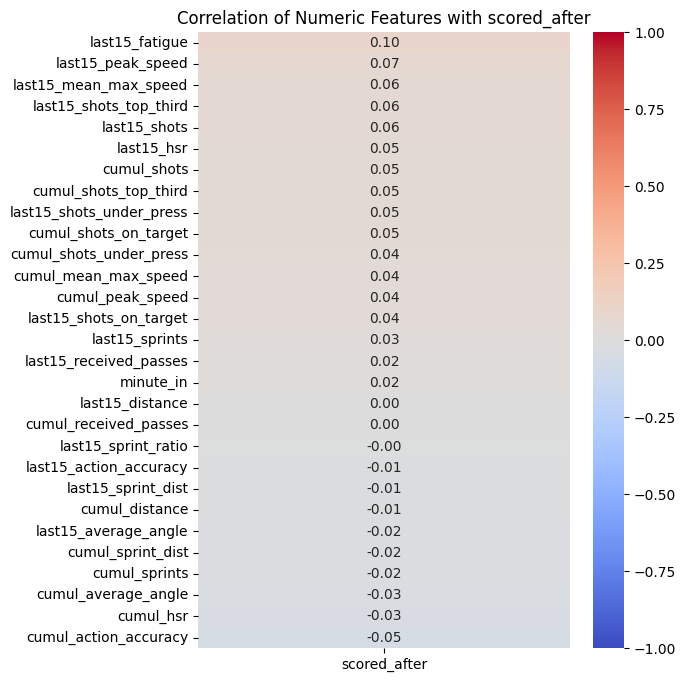

In [6]:
# Correlation Analysis
plt.figure(figsize=(6, 8))
corr = X.corr()
corr_target = corr[['scored_after']].drop('scored_after').sort_values(by='scored_after', ascending=False)

sns.heatmap(corr_target, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation of Numeric Features with scored_after')

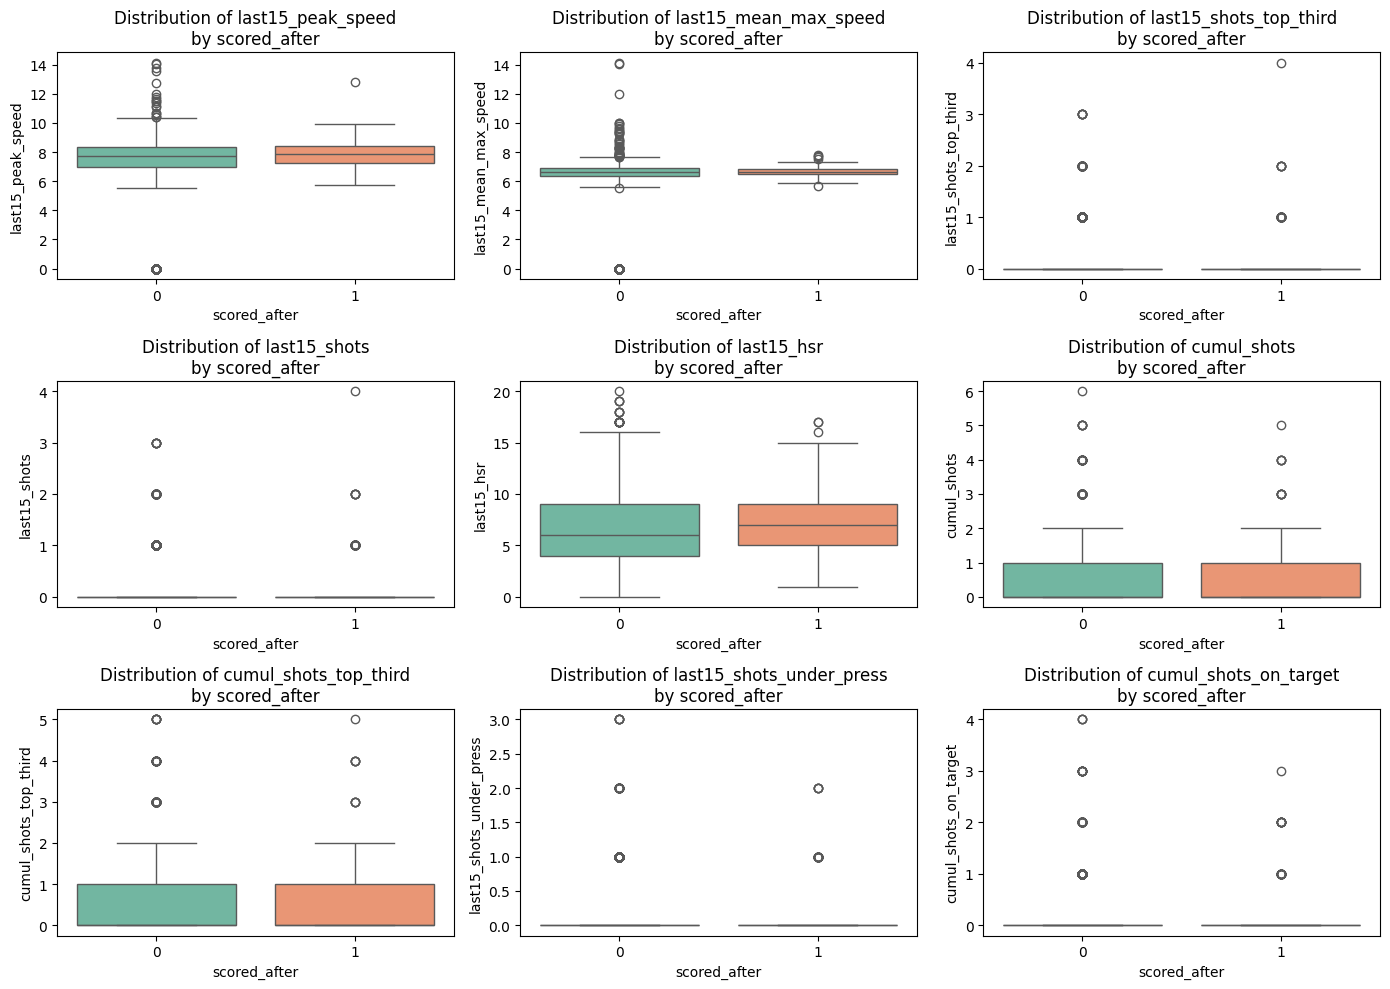

In [ ]:
# Boxplots for Top Correlated Features
top_features = corr_target.abs().nlargest(9, 'scored_after').index

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(top_features):
    sns.boxplot(x='scored_after', y=col, data=df, ax=axes[i], palette='Set2',
                hue = "scored_after", legend = False)
    axes[i].set_title(f'Distribution of {col}\nby scored_after')
plt.tight_layout()

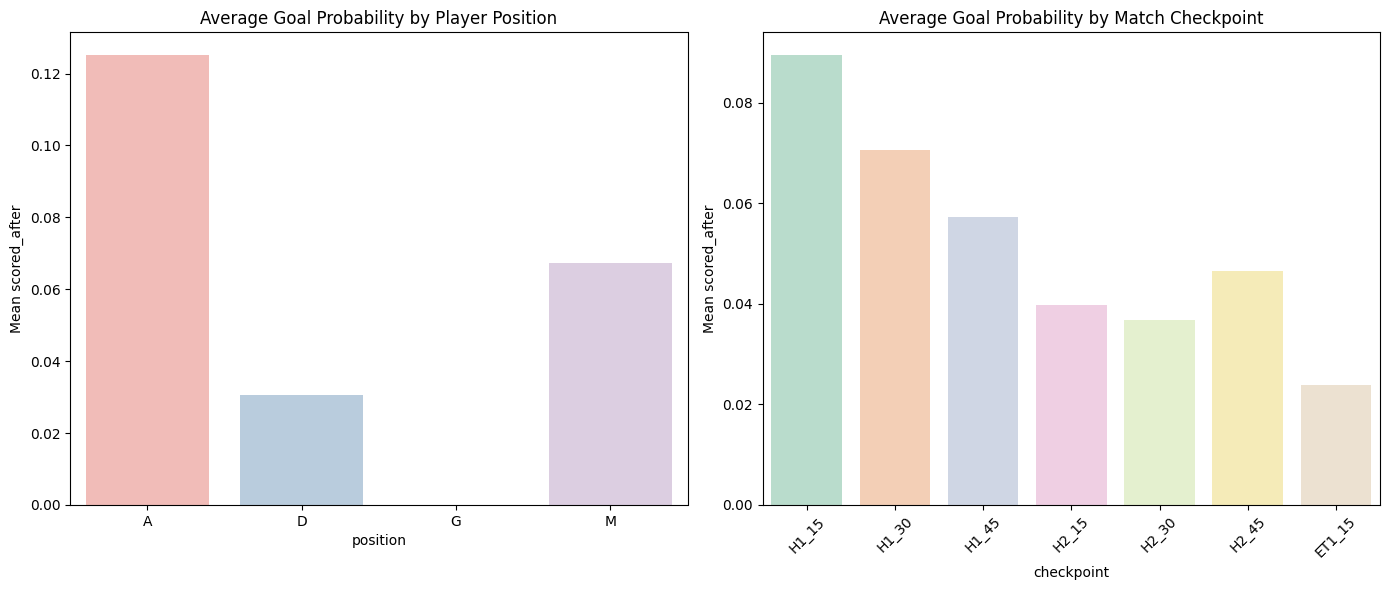

In [ ]:
# Categorical Relationships
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Mean scored_after by Position
sns.barplot(x='position', y='scored_after', data=df, ax=axes[0], palette='Pastel1', errorbar=None,
            hue = 'position', legend = False)
axes[0].set_title('Average Goal Probability by Player Position')
axes[0].set_ylabel('Mean scored_after')

# Mean scored_after by Checkpoint
sns.barplot(x='checkpoint', y='scored_after', data=df, ax=axes[1], palette='Pastel2', errorbar=None,
            hue = 'checkpoint', legend = False)
axes[1].set_title('Average Goal Probability by Match Checkpoint')
axes[1].set_ylabel('Mean scored_after')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()

## t-SNE

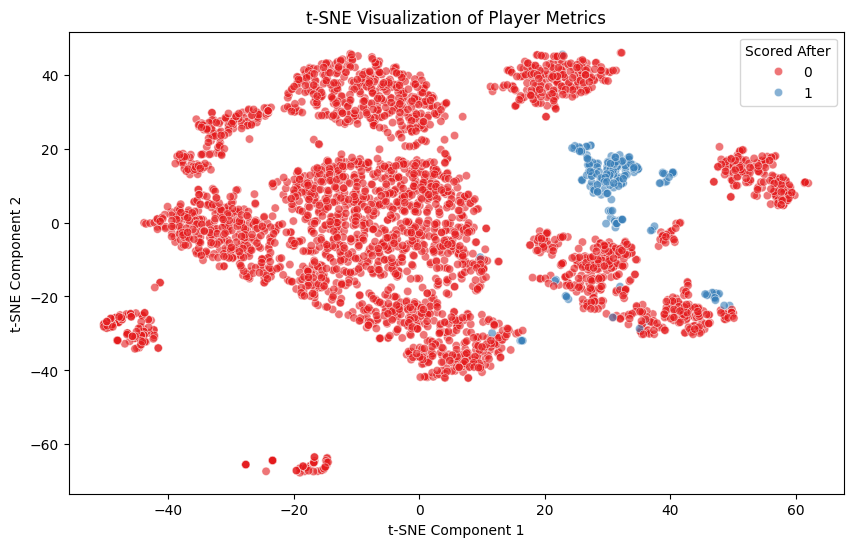

In [7]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto',
            perplexity = 45)
tsne_result = tsne.fit_transform(X_scaled)

# Add t-SNE results back to the dataframe for plotting
df['tSNE1'] = tsne_result[:, 0]
df['tSNE2'] = tsne_result[:, 1]

# 4. Plot t-SNE Scatter Plot
plt.figure(figsize=(10, 6))

# Treat scored_after as categorical for coloring
is_binary = df['scored_after'].nunique() <= 2
hue_type = df['scored_after'].astype(str) if is_binary else 'scored_after'

sns.scatterplot(
    x='tSNE1', y='tSNE2',
    hue=hue_type,
    data=df,
    palette='Set1' if is_binary else 'viridis',
    alpha=0.6
)

plt.title('t-SNE Visualization of Player Metrics')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(title='Scored After')